In [1]:
from dotenv import load_dotenv

load_dotenv(override=True)

True

## MultiServerMCPClient

사전에 `mcp_server_remote(http).py` 를 실행해둡니다. 터미널을 열고 가상환경이 활성화 되어 있는 상태에서 서버를 실행해 주세요.

> 명령어
```bash
source .dotenv/script/activate
python mcp_server_remote(http).py
```

`async with` 로 일시적인 Session 연결을 생성 후 해제

In [ ]:
# 오류가 나는 이유: langchain-mcp-adapters 0.1.0부터 MultiServerMCPClient는 async context manager(`async with`) 또는 __aenter__를 사용할 수 없습니다.
# MultiServerMCPClient를 통해 MCP 서버에서 도구 목록을 받아와서,
# 해당 도구들을 LangGraph의 create_react_agent에 연결하여 에이전트를 생성하고,
# ainvoke_graph를 통해 실제로 에이전트가 도구를 사용할 수 있도록 하는 전체 흐름입니다.
# langchain-mcp-adapters 0.1.0 버전부터 MultiServerMCPClient를 async context manager(`async with`)로 사용할 수 없습니다.
# 공식 메시지에 따르면, 아래와 같이 사용해야 합니다.

# python .\mcp_rag_http.py
from langchain_mcp_adapters.client import MultiServerMCPClient
# from langgraph.prebuilt import create_react_agent
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from utils import ainvoke_graph, astream_graph

model = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

# MCP 서버에 연결하여 도구 목록을 받아옵니다.
client = MultiServerMCPClient(
    {
        "name": {
            "url": "http://localhost:8103/mcp",
            "transport": "streamable_http",
        }
    }
)
tools = await client.get_tools()  # MCP에서 도구를 받아옴

# 받아온 도구를 LangGraph 에이전트에 연결
agent = create_agent(model, tools)

# 에이전트가 도구를 활용하여 질문에 답변하도록 실행
answer = await ainvoke_graph(agent, {"messages": "Jaeho"})

  + Exception Group Traceback (most recent call last):
  |   File "c:\Users\skyop\jaeho_template\dotenv\Lib\site-packages\IPython\core\interactiveshell.py", line 3697, in run_code
  |     await eval(code_obj, self.user_global_ns, self.user_ns)
  |   File "C:\Users\skyop\AppData\Local\Temp\ipykernel_32528\183710670.py", line 25, in <module>
  |     tools = await client.get_tools()  # MCP에서 도구를 받아옴
  |             ^^^^^^^^^^^^^^^^^^^^^^^^
  |   File "c:\Users\skyop\jaeho_template\dotenv\Lib\site-packages\langchain_mcp_adapters\client.py", line 187, in get_tools
  |     tools_list = await asyncio.gather(*load_mcp_tool_tasks)
  |                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  |   File "c:\Users\skyop\jaeho_template\dotenv\Lib\site-packages\langchain_mcp_adapters\tools.py", line 348, in load_mcp_tools
  |     async with create_session(
  |   File "C:\Users\skyop\.pyenv\pyenv-win\versions\3.11.9\Lib\contextlib.py", line 231, in __aexit__
  |     await self.gen.athrow(typ, valu

In [ ]:
await astream_graph(agent, {"messages": "jaeho"})


[Node: agent]
- - - - - - - - - - - - - - - - - - - - - - - - - 

[Node: tools]
- - - - - - - - - - - - - - - - - - - - - - - - - 
My name is jaeho
[Node: agent]
- - - - - - - - - - - - - - - - - - - - - - - - - 
Hello, jaeho! How can I assist you today?

{'node': 'agent',
 'content': AIMessageChunk(content='', additional_kwargs={}, response_metadata={}, id='lc_run--72775984-ed68-4191-b776-5361355cd6dd', chunk_position='last'),
 'metadata': {'langgraph_step': 3,
  'langgraph_node': 'agent',
  'langgraph_triggers': ('branch:to:agent',),
  'langgraph_path': ('__pregel_pull', 'agent'),
  'langgraph_checkpoint_ns': 'agent:40bea90a-8fb1-3ab5-8024-46adb459f099',
  'checkpoint_ns': 'agent:40bea90a-8fb1-3ab5-8024-46adb459f099',
  'ls_provider': 'openai',
  'ls_model_name': 'gpt-4.1-mini',
  'ls_model_type': 'chat',
  'ls_temperature': 0.0,
  'revision_id': '3562c6b-dirty'}}

In [ ]:
# 에이전트 생성
# client.get_tools()는 coroutine이므로 await로 받아야 함
tools = await client.get_tools()
agent = create_agent(model, tools)

  + Exception Group Traceback (most recent call last):
  |   File "c:\Users\skyop\jaeho_template\dotenv\Lib\site-packages\IPython\core\interactiveshell.py", line 3697, in run_code
  |     await eval(code_obj, self.user_global_ns, self.user_ns)
  |   File "C:\Users\skyop\AppData\Local\Temp\ipykernel_32528\1513998405.py", line 3, in <module>
  |     tools = await client.get_tools()
  |             ^^^^^^^^^^^^^^^^^^^^^^^^
  |   File "c:\Users\skyop\jaeho_template\dotenv\Lib\site-packages\langchain_mcp_adapters\client.py", line 187, in get_tools
  |     tools_list = await asyncio.gather(*load_mcp_tool_tasks)
  |                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  |   File "c:\Users\skyop\jaeho_template\dotenv\Lib\site-packages\langchain_mcp_adapters\tools.py", line 348, in load_mcp_tools
  |     async with create_session(
  |   File "C:\Users\skyop\.pyenv\pyenv-win\versions\3.11.9\Lib\contextlib.py", line 231, in __aexit__
  |     await self.gen.athrow(typ, value, traceback)
  |

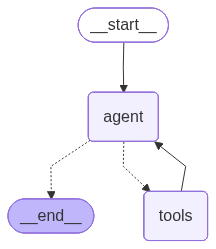

In [ ]:
agent

In [5]:
await astream_graph(agent, {"messages": "Jaeho"})


[Node: agent]
- - - - - - - - - - - - - - - - - - - - - - - - - 
Hello! How can I assist you today?

{'node': 'agent',
 'content': AIMessageChunk(content='', additional_kwargs={}, response_metadata={}, id='lc_run--9fa56f21-91c2-427a-b980-7a47ff23edaa', chunk_position='last'),
 'metadata': {'langgraph_step': 1,
  'langgraph_node': 'agent',
  'langgraph_triggers': ('branch:to:agent',),
  'langgraph_path': ('__pregel_pull', 'agent'),
  'langgraph_checkpoint_ns': 'agent:26fc0de4-8c4c-63dd-126a-d54ea4727935',
  'checkpoint_ns': 'agent:26fc0de4-8c4c-63dd-126a-d54ea4727935',
  'ls_provider': 'openai',
  'ls_model_name': 'gpt-4.1-mini',
  'ls_model_type': 'chat',
  'ls_temperature': 0.0,
  'revision_id': '3562c6b-dirty'}}

## Stdio 통신 방식

Stdio 통신 방식은 로컬 환경에서 사용하기 위해 사용합니다.

- 통신을 위해 표준 입력/출력 사용

참고: 아래의 python 경로는 수정하세요!

다음은 윈도우 환경에서의 stdio 방식을 사용하기 위한 코드입니다.

Jupyter의 stderr 대신 subprocess.PIPE를 쓰도록 강제로 리디렉션하는 방식입니다.

In [1]:
import subprocess
from langchain_mcp_adapters import sessions as mcp_sessions

print("🛠️ patching stdio_client...")


_original_stdio_client = mcp_sessions.stdio_client

def patched_stdio_client(server, errlog=None):
    # 호출 확인용
    print("patched_stdio_client 호출됨 (errlog=", errlog, ")")

    # LangChain이 errlog=None으로 넘기므로
    # Jupyter stderr 대신 직접 PIPE로 바꿔줌
    if errlog is None:
        errlog = subprocess.PIPE

    return _original_stdio_client(server, errlog=errlog)

# monkey patch 적용
mcp_sessions.stdio_client = patched_stdio_client

print("stdio_client 패치 완료:", mcp_sessions.stdio_client)

🛠️ patching stdio_client...
stdio_client 패치 완료: <function patched_stdio_client at 0x00000259FFD32700>


In [2]:
from typing import List, Dict, Any
from langchain_mcp_adapters.client import MultiServerMCPClient
# MultiServerMCPClient 설정 예제
async def setup_mcp_client(server_configs: List[Dict[str, Any]]):
    """MCP 클라이언트를 설정하고 도구를 가져옵니다."""

    # MCP 클라이언트 생성
    client = MultiServerMCPClient(server_configs)

    # 도구 가져오기
    tools = await client.get_tools()

    print(f"✅ {len(tools)} 개의 MCP 도구가 로드되었습니다:")
    for tool in tools:
        print(f"  - {tool.name}")

    return client, tools

In [3]:
# 서버 구성 정의
server_configs = {
    "weather": {
        "command": "python",
        "args": ["mcp_server_local_stdio.py"],
        "transport": "stdio",
    },
}

# MCP 클라이언트 생성
client, tools = await setup_mcp_client(server_configs=server_configs)

patched_stdio_client 호출됨 (errlog= None )
✅ 1 개의 MCP 도구가 로드되었습니다:
  - get_name


In [4]:
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver

# LLM 설정
llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

# React Agent 생성
agent = create_agent(
    llm, tools, checkpointer=InMemorySaver()  # 상태 저장을 위한 체크포인터
)

In [5]:
from langchain_teddynote.messages import astream_graph, random_uuid
from langchain_core.runnables import RunnableConfig

config = RunnableConfig(configurable={"thread_id": random_uuid()})

response = await astream_graph(
    agent,
    inputs={"messages": [("human", "Jaeho")]},
    config=config,
)


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
patched_stdio_client 호출됨 (errlog= None )

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
My name is Jaeho
🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
Your name is Jaeho. How can I assist you today?

----------

In [6]:
# qdrant에서 불러오기 때문에 docker를 켜야한다.

In [9]:
# 서버 구성 정의
server_configs = {
    "weather": {
        "command": "python",
        "args": ["mcp_rag_stdio_qdrant.py"],
        "transport": "stdio",
    },
}

# MCP 클라이언트 생성
client, retriever_tools = await setup_mcp_client(server_configs=server_configs)

patched_stdio_client 호출됨 (errlog= None )
✅ 1 개의 MCP 도구가 로드되었습니다:
  - retrieve


In [10]:
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver

# LLM 설정
llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

# React Agent 생성
retrieve_agent = create_agent(
    llm, retriever_tools, checkpointer=InMemorySaver()  # 상태 저장을 위한 체크포인터
)

In [11]:
from langchain_teddynote.messages import astream_graph, random_uuid
from langchain_core.runnables import RunnableConfig

config = RunnableConfig(configurable={"thread_id": random_uuid()})

response = await astream_graph(
    retrieve_agent,
    inputs={"messages": [("human", "DNA서 열예측")]},
    config=config,
)


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
patched_stdio_client 호출됨 (errlog= None )

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
<!-- image -->

## 기술 ･ 연구

<!-- image -->

## 구글 딥마인드, 인간 DNA 염기서열 분석 AI 모델 '알파게놈' 공개

## KEY Contents

- n 구글 딥마인드가 인간 DNA 염기서열을 입력하면 수천 개에 달하는 분자적 특성을 예측할 수 있는 AI 모델 '알파게놈'을 개발하고 비상업적 연구용으로 API로 공개
- n 알파게놈은 유전체의 98%에 해당하는 단백질 비부호화 영역을 해독할 수 있으며, 광범위한 유전체 예측 벤치마크 평가에서 기존 최고 성능 모델과 동등하거나 더 뛰어난 수준의 성능을 달성

## £ 알파게놈, 최대 100만 개의 DNA 염기서열을 바탕으로 수천 종류의 분자적 특성 예측

- n 구글 딥마인드(Google Deepmind)가 2025년 6월 25일 인간 DNA 염기서열*의 변이가 유전자 활동에 미치는 영향을 예측할 수 있는 AI 모델 '알파게놈(AlphaGenome)'을 공개
* DNA의 기본 단위로 유전 형질을 구성하는 염기(아데닌(A), 구아닌(G), 시토신(C), 티민(T))가 배열된 순서
- 유전체(Genome)는 생명체의 거의 모든 부분을 안내하는 완전한 DNA 세트로서, DNA 서열의 변이는 생명체의 환경 적응력이나 질병 반응을 변화시킬 수 있으나, 유전체의 상당 부분은 여전히 생물학의 난제로 평가
- 알파게놈은 최대 100만 개의 문자(염기쌍*)로 구성된 긴 DNA 염기서열 입력 시 수천 종류에 달하는 분자적 특성(예: 세포 유형, 리보핵산(RNA)의 생산량, 특정 단백질에 결합하는 DNA 염기)을 예측
* 이중나선 구조로 되어 있는 DNA의 두 가닥이 결합하여 생기

# `mcp_local(stdio).py` 에서 돌려보기

In [ ]:
# from mcp import ClientSession, StdioServerParameters
# from mcp.client.stdio import stdio_client
# from langgraph.prebuilt import create_react_agent
# from langchain_mcp_adapters.tools import load_mcp_tools

# # command 위치가 맞는지 확인하려면, 실제 파이썬 인터프리터 경로가 맞는지 확인해야 합니다.
# # 예를 들어, 윈도우 환경에서는 보통 "python" 또는 "python.exe" 경로가 다를 수 있습니다.
# # 아래처럼 sys.executable을 사용하면 현재 실행 중인 파이썬 경로를 쓸 수 있습니다.

# import sys

# server_params = StdioServerParameters(
#     command=sys.executable,  # 현재 파이썬 인터프리터 경로 사용
#     args=["mcp_local_local(stdio).py"],
# )

# # StdIO 클라이언트를 사용하여 서버와 통신
# async with stdio_client(server_params) as (read, write):
#     # 클라이언트 세션 생성
#     async with ClientSession(read, write) as session:
#         # 연결 초기화
#         await session.initialize()

#         # MCP 도구 로드
#         tools = await load_mcp_tools(session)
#         print(tools)

#         # 에이전트 생성
#         agent = create_react_agent(model, tools)

#         # 에이전트 응답 스트리밍
#         await astream_graph(agent, {"messages": "jaeho"})

# Retriever MCP (mcp_rag_sse.py)

mcp_rag_http.py가 켜져야 하며,
docker에서 qdrant에 데이터 정보가 저장되어 있으므로, docker를 반드시 켜야한다.

In [ ]:
# MultiServerMCPClient를 통해 MCP 서버에서 도구 목록을 받아와서,
# 해당 도구들을 LangGraph의 create_react_agent에 연결하여 에이전트를 생성하고,
# ainvoke_graph를 통해 실제로 에이전트가 도구를 사용할 수 있도록 하는 전체 흐름입니다.
# langchain-mcp-adapters 0.1.0 버전부터 MultiServerMCPClient를 async context manager(`async with`)로 사용할 수 없습니다.
# 공식 메시지에 따르면, 아래와 같이 사용해야 합니다.


from langchain_mcp_adapters.client import MultiServerMCPClient
from langgraph.prebuilt import create_react_agent
from langchain_openai import ChatOpenAI
from utils import ainvoke_graph, astream_graph

model = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

# MCP 서버에 연결하여 도구 목록을 받아옵니다.
client = MultiServerMCPClient(
    {
        "name": {
            "url": "http://localhost:8102/sse",
            "transport": "sse",
        }
    }
)
tools = await client.get_tools()  # MCP에서 도구를 받아옴

# 받아온 도구를 LangGraph 에이전트에 연결
agent = create_agent(model, tools)

# 에이전트가 도구를 활용하여 질문에 답변하도록 실행
answer = await ainvoke_graph(agent, {"messages": "spri에 미드저니에 대한 정보가 있어?"})

C:\Users\skyop\AppData\Local\Temp\ipykernel_32528\365055702.py:27: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(model, tools)



🔄 Node: agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================
Tool Calls:
  retrieve (call_mceA4xoCR4myjCOoCm91JdQo)
 Call ID: call_mceA4xoCR4myjCOoCm91JdQo
  Args:
    query: 미드저니

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================= Tool Message =================================
Name: retrieve

- n AI 이미지 생성 플랫폼 미드저니(Midjourney)가 2025년 6월 19일 비디오 생성 모델 'V1'을 출시
- V1은 이미지를 동영상으로 변환하는 모델로, 미드저니 플랫폼에서 제작된 이미지나 외부 이미지를 바탕으로 동영상을 생성하며, '자동' 설정 시에는 모션 프롬프트가 자동으로 생성되고 '수동' 설정을 선택하면 사용자 지시에 따라 사물이나 장면의 움직임을 생성
- 사용자는 움직임 강도를 피사체와 카메라가 모두 움직이는 '하이 모션(High Motion)'과 카메라는 거의 고정되어 있고 피사체가 천천히 움직이도록 연출 '로우 모션(Low Motion)' 중에서 선택 가능
- 웹 전용 모델인 V1은 1회 동영상 생성 작업으로 5초 길이의 동영상 4개를 제작하며, 생성된 동영상은 한 번에 4초씩 최대 4회까지 영상 길이를 확장할 수 있도록 허용
<!-- image -->

## 기업 ･ 산업

<!-- image -->

## 미드저니, 첫 번째 비디오 생성 AI 모델 'V1' 출시

## KEY Contents

- n 미드저니가 1회 작업으로 5초 길이의 동영상 4개를 제작할 수 있는 

In [ ]:
# MultiServerMCPClient를 통해 MCP 서버에서 도구 목록을 받아와서,
# 해당 도구들을 LangGraph의 create_react_agent에 연결하여 에이전트를 생성하고,
# ainvoke_graph를 통해 실제로 에이전트가 도구를 사용할 수 있도록 하는 전체 흐름입니다.
# langchain-mcp-adapters 0.1.0 버전부터 MultiServerMCPClient를 async context manager(`async with`)로 사용할 수 없습니다.
# 공식 메시지에 따르면, 아래와 같이 사용해야 합니다.


from langchain_mcp_adapters.client import MultiServerMCPClient
from langgraph.prebuilt import create_react_agent
from langchain_openai import ChatOpenAI
from utils import ainvoke_graph, astream_graph

model = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

# MCP 서버에 연결하여 도구 목록을 받아옵니다.
client = MultiServerMCPClient(
    {
        "name": {
            "url": "http://localhost:8102/sse",
            "transport": "sse",
        }
    }
)
tools = await client.get_tools()  # MCP에서 도구를 받아옴

# 받아온 도구를 LangGraph 에이전트에 연결
agent = create_agent(model, tools)

# 에이전트가 도구를 활용하여 질문에 답변하도록 실행
answer = await ainvoke_graph(agent, {"messages": "단백질 서열 예측"})

C:\Users\skyop\AppData\Local\Temp\ipykernel_32528\1840369620.py:27: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(model, tools)



🔄 Node: agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================
Tool Calls:
  retrieve (call_SHrwHPAeeetRRvDfmoHJWsRe)
 Call ID: call_SHrwHPAeeetRRvDfmoHJWsRe
  Args:
    query: 단백질 서열 예측

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================= Tool Message =================================
Name: retrieve

<!-- image -->

## 기술 ･ 연구

<!-- image -->

## 구글 딥마인드, 인간 DNA 염기서열 분석 AI 모델 '알파게놈' 공개

## KEY Contents

- n 구글 딥마인드가 인간 DNA 염기서열을 입력하면 수천 개에 달하는 분자적 특성을 예측할 수 있는 AI 모델 '알파게놈'을 개발하고 비상업적 연구용으로 API로 공개
- n 알파게놈은 유전체의 98%에 해당하는 단백질 비부호화 영역을 해독할 수 있으며, 광범위한 유전체 예측 벤치마크 평가에서 기존 최고 성능 모델과 동등하거나 더 뛰어난 수준의 성능을 달성

## £ 알파게놈, 최대 100만 개의 DNA 염기서열을 바탕으로 수천 종류의 분자적 특성 예측
* 유전체의 2%를 차지하는 단백질 부호화 영역 내 변이 영향의 분류에 특화된 AI 모델   ** 유전체 중 단백질로 발현되지 않는 영역
- 유전자 활동 조율에 필수적이면서 질병과 관련된 다양한 변이를 포함하는 단백질 비부호화 영역의 광범위한 염기서열과 변이의 해석을 지원하며, 돌연변이가 발생한 염기서열과 발생하지 않은 염기서열의 예측값을 비교하여 유전적

# Manse tool MCP (mcp_manse_sse.py)

mcp_manse_sse.py가 켜져야 하며,
docker에서 qdrant에 데이터 정보가 저장되어 있으므로, docker를 반드시 켜야한다.

In [ ]:
# MultiServerMCPClient를 통해 MCP 서버에서 도구 목록을 받아와서,
# 해당 도구들을 LangGraph의 create_react_agent에 연결하여 에이전트를 생성하고,
# ainvoke_graph를 통해 실제로 에이전트가 도구를 사용할 수 있도록 하는 전체 흐름입니다.
# langchain-mcp-adapters 0.1.0 버전부터 MultiServerMCPClient를 async context manager(`async with`)로 사용할 수 없습니다.
# 공식 메시지에 따르면, 아래와 같이 사용해야 합니다.


from langchain_mcp_adapters.client import MultiServerMCPClient
#from langgraph.prebuilt import create_react_agent
from langchain_openai import ChatOpenAI
from utils import ainvoke_graph, astream_graph

model = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

# MCP 서버에 연결하여 도구 목록을 받아옵니다.
client = MultiServerMCPClient(
    {
        "name": {
            "url": "http://localhost:8104/sse",
            "transport": "sse",
        }
    }
)
tools = await client.get_tools()  # MCP에서 도구를 받아옴

# 받아온 도구를 LangGraph 에이전트에 연결
agent = create_agent(model, tools)

# 에이전트가 도구를 활용하여 질문에 답변하도록 실행
answer = await ainvoke_graph(agent, {"messages": "1995년 3월 28일 12시 30분 출생 사주봐줘. 자세히 풀이까지 해줘"})

C:\Users\skyop\AppData\Local\Temp\ipykernel_32528\158031901.py:27: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(model, tools)



🔄 Node: agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================
Tool Calls:
  parse_saju_input (call_MWrR18xVcufRzDO0dn2PA3t2)
 Call ID: call_MWrR18xVcufRzDO0dn2PA3t2
  Args:
    text: 1995년 3월 28일 12시 30분 남자

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================= Tool Message =================================
Name: parse_saju_input

파싱 결과:
{
  "year": 1995,
  "month": 3,
  "day": 28,
  "hour": 12,
  "minute": 30,
  "is_male": true,
  "is_leap_month": false
}

🔄 Node: agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================
Tool Calls:
  calculate_saju (call_MYFsjnh2V7EiClmYRDYNNqxg)
 Call ID: call_MYFsjnh2V7EiClmYRDYNNqxg
  Args:
    year: 1995
    month: 3
    day: 28
    hour: 12
    minute: 30
    is_male: True
    is_leap_month: False

🔄 Node: tools 🔄
- - - - - - - - - -

# MCP_RAG_http.py

In [ ]:
# MultiServerMCPClient를 통해 MCP 서버에서 도구 목록을 받아와서,
# 해당 도구들을 LangGraph의 create_react_agent에 연결하여 에이전트를 생성하고,
# ainvoke_graph를 통해 실제로 에이전트가 도구를 사용할 수 있도록 하는 전체 흐름입니다.
# langchain-mcp-adapters 0.1.0 버전부터 MultiServerMCPClient를 async context manager(`async with`)로 사용할 수 없습니다.
# 공식 메시지에 따르면, 아래와 같이 사용해야 합니다.


from langchain_mcp_adapters.client import MultiServerMCPClient
from langgraph.prebuilt import create_react_agent
from langchain_openai import ChatOpenAI
from utils import ainvoke_graph, astream_graph

model = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

# MCP 서버에 연결하여 도구 목록을 받아옵니다.
client = MultiServerMCPClient(
    {
        "name": {
            "url": "http://localhost:8103/mcp",
            "transport": "streamable_http",
        }
    }
)
tools = await client.get_tools()  # MCP에서 도구를 받아옴

# 받아온 도구를 LangGraph 에이전트에 연결
agent = create_agent(model, tools)

# 에이전트가 도구를 활용하여 질문에 답변하도록 실행
answer = await ainvoke_graph(agent, {"messages": "DNA서열예측"})


#     "current_time": {
#         "url": "http://127.0.0.1:8003/mcp",
#         "transport": "streamable_http",
#     },
# }


C:\Users\skyop\AppData\Local\Temp\ipykernel_32528\3784083399.py:27: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(model, tools)



🔄 Node: agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================
Tool Calls:
  retrieve (call_qRZAomu3kPX6eiXx9IqhZRqH)
 Call ID: call_qRZAomu3kPX6eiXx9IqhZRqH
  Args:
    query: DNA 서열 예측

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================= Tool Message =================================
Name: retrieve

<!-- image -->

## 기술 ･ 연구

<!-- image -->

## 구글 딥마인드, 인간 DNA 염기서열 분석 AI 모델 '알파게놈' 공개

## KEY Contents

- n 구글 딥마인드가 인간 DNA 염기서열을 입력하면 수천 개에 달하는 분자적 특성을 예측할 수 있는 AI 모델 '알파게놈'을 개발하고 비상업적 연구용으로 API로 공개
- n 알파게놈은 유전체의 98%에 해당하는 단백질 비부호화 영역을 해독할 수 있으며, 광범위한 유전체 예측 벤치마크 평가에서 기존 최고 성능 모델과 동등하거나 더 뛰어난 수준의 성능을 달성

## £ 알파게놈, 최대 100만 개의 DNA 염기서열을 바탕으로 수천 종류의 분자적 특성 예측
- n 구글 딥마인드(Google Deepmind)가 2025년 6월 25일 인간 DNA 염기서열*의 변이가 유전자 활동에 미치는 영향을 예측할 수 있는 AI 모델 '알파게놈(AlphaGenome)'을 공개
* DNA의 기본 단위로 유전 형질을 구성하는 염기(아데닌(A), 구아닌(G), 시토신(C), 티민(T))가 배열된 순서
- 유전체(Genome)는 

# Manse tool MCP (mcp_manse_http.py)

mcp_manse_sse.py가 켜져야 하며,
docker에서 qdrant에 데이터 정보가 저장되어 있으므로, docker를 반드시 켜야한다.

In [ ]:
from langchain_mcp_adapters.client import MultiServerMCPClient
from langgraph.prebuilt import create_react_agent
from langchain_openai import ChatOpenAI
from utils import ainvoke_graph, astream_graph

model = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

# MCP 서버에 연결하여 도구 목록을 받아옵니다.
client = MultiServerMCPClient(
    {
        "name": {
            "url": "http://localhost:8105/mcp",
            "transport": "streamable_http",
        }
    }
)
tools = await client.get_tools()  # MCP에서 도구를 받아옴

# 받아온 도구를 LangGraph 에이전트에 연결
agent = create_agent(model, tools)

# 에이전트가 도구를 활용하여 질문에 답변하도록 실행

answer = await ainvoke_graph(agent, {"messages": "1995년 3월 28일 12시 30분 출생 사주봐줘. 자세히 풀이까지 해줘"})

C:\Users\skyop\AppData\Local\Temp\ipykernel_32528\3378551504.py:20: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(model, tools)



🔄 Node: agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================
Tool Calls:
  parse_saju_input (call_pJVTjwr6ninG6GEUbJmgoEUH)
 Call ID: call_pJVTjwr6ninG6GEUbJmgoEUH
  Args:
    text: 1995년 3월 28일 12시 30분 남자

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================= Tool Message =================================
Name: parse_saju_input

파싱 결과:
{
  "year": 1995,
  "month": 3,
  "day": 28,
  "hour": 12,
  "minute": 30,
  "is_male": true,
  "is_leap_month": false
}

🔄 Node: agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================
Tool Calls:
  calculate_saju (call_cj44hDZJlOa2vQ4y9Z1u156s)
 Call ID: call_cj44hDZJlOa2vQ4y9Z1u156s
  Args:
    year: 1995
    month: 3
    day: 28
    hour: 12
    minute: 30
    is_male: True
    is_leap_month: False

🔄 Node: tools 🔄
- - - - - - - - - -

## SSE 방식과 Stdio 방식 혼합 사용

- 파일: `mcp_server_rag.py` 는 StdIO 방식으로 통신
- `langchain-dev-docs` 는 SSE 방식으로 통신
- `manse-tool`은 SSEㅂ 방식으로 통신
SSE 방식과 StdIO 방식을 혼합하여 사용합니다.

`mcp_client_openai.py` 참고

In [ ]:
# import sys
# # 아래 코드는 Jupyter 노트북이 아닌, 터미널(명령 프롬프트, bash 등)에서 실행할 수 있는 Python 파일 예시입니다.
# # 파일명 예시: mcp_multiserver_client.py

# import sys
# import asyncio
# from langchain_mcp_adapters.client import MultiServerMCPClient
# from langgraph.prebuilt import create_react_agent
# from langchain_openai import ChatOpenAI

# async def main():
#     model = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

#     # 1. 다중 서버 MCP 클라이언트 생성 (document-retriever는 stdio, langchain-dev-docs는 sse)
#     client = MultiServerMCPClient(
#         {
#             "document-retriever": {
#                 "command": sys.executable,  # 현재 파이썬 실행 파일 경로
#                 "args": ["mcp_server_local(stdio).py"],  # mcp_server_rag.py의 경로를 실제 위치로 수정
#                 "transport": "stdio",
#             },
#             "langchain-dev-docs": {
#                 "url": "https://teddynote.io/mcp/langchain/sse",
#                 "transport": "sse",
#             },
#             "manse-tool":{
#                 "url": "http://localhost:8102/sse",
#                 "transport": "sse"
#             }
#         }
#     )

#     # 2. 도구 목록 받아오기
#     tools = await client.get_tools()

#     # 3. LangGraph 에이전트 생성
#     agent = create_react_agent(model, tools)

#     # 4. 에이전트에게 질문하기 (예시)
#     from utils import ainvoke_graph
#     answer = await ainvoke_graph(agent, {"messages": "1995년 3월 28일 12시 30분 출생 사주봐줘. 자세히 풀이까지 해줘"})
#     print(answer)

# if __name__ == "__main__":
#     asyncio.run(main())

# Multi SSE MCP

In [ ]:
# Jupyter 노트북 환경에서는 stdio transport가 정상적으로 동작하지 않습니다.
# (UnsupportedOperation: fileno 에러 발생)
# 따라서 stdio 대신 sse 방식만 사용하거나, stdio는 터미널에서만 사용하세요.

from langchain_mcp_adapters.client import MultiServerMCPClient
from langgraph.prebuilt import create_react_agent
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.runnables import RunnableConfig

model = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

# document-retriever도 sse 방식으로 예시를 변경 (실제 서버 주소로 수정 필요)
client = MultiServerMCPClient(
    {
        "mcp-rag-sse": {
            "url": "http://localhost:8102/sse",  # 실제 SSE 서버 주소로 변경
            "transport": "sse",
        },
        "mcp-rag-http": {
            "url": "http://localhost:8103/sse",  # 실제 SSE 서버 주소로 변경
            "transport": "streamable-http",
        },
        "langchain-dev-docs": {
            "url": "https://teddynote.io/mcp/langchain/sse",
            "transport": "sse",
        },
        "manse-tool-sse":{
            "url": "http://localhost:8104/sse",
            "transport": "sse"
        },
        "manse-tool-http":{
            "url": "http://localhost:8105/sse",
            "transport": "streamable-http"
        },
    }
)

tools = await client.get_tools()

ValueError: Unsupported transport: streamable-http. Must be one of: 'stdio', 'sse', 'websocket', 'streamable_http'

langgraph 의 `create_react_agent` 를 사용하여 에이전트를 생성합니다.

In [ ]:
# from langchain_mcp_adapters.client import MultiServerMCPClient
# from langgraph.prebuilt import create_react_agent
# from langchain_openai import ChatOpenAI
# from utils import ainvoke_graph, astream_graph
# from langgraph.checkpoint.memory import MemorySaver
# from langchain_core.runnables import RunnableConfig
# from langchain_openai import ChatOpenAI

# model = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

prompt = (
    "You are a smart agent. Answer in Korean.\n"
    "- `mcp-rag` : search SPRI AI docs; cite title/date.\n"
    "- `langchain-dev-docs` : search LangChain/LangGraph docs; return API path + short code.\n"
    "- `manse-tool` : when birth date and time are provided, use it to read Saju (Four Pillars) and return pillars/day-master/five-elements.\n"
)

# 오류 원인: client.get_tools()는 awaitable 객체(코루틴)인데, await 없이 바로 전달해서 발생합니다.
# Jupyter 환경에서는 await를 써야 하므로 아래처럼 수정해야 합니다.
agent = create_agent(
    model, tools, prompt=prompt, checkpointer=MemorySaver()
)

C:\Users\skyop\AppData\Local\Temp\ipykernel_31800\692738138.py:20: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


In [ ]:
config = RunnableConfig(recursion_limit=30, thread_id=1)
await astream_graph(
    agent,
    {
        "messages": "DNA 서열 예측에서 최고 성능 개수는?"
    },
    config=config,
)


[Node: agent]
- - - - - - - - - - - - - - - - - - - - - - - - - 

[Node: tools]
- - - - - - - - - - - - - - - - - - - - - - - - - 
* SpliceAI, Borzoi, ProCapNet, Panglon, ChromBPNet, Orca, Enformer, AbSplice
- DNA 서열 예측에서는 24개 평가 과제 중 22개에서 최고 성능을 보였고, 변이의 조절 효과 예측에서는 26개 평가 과제 중 24개에서 기존 최고 성능 모델과 동등하거나 능가하는 기록을 달성
- n 그러나 알파게놈은 유전자와 해당 기능을 조절하는 요소가 10만 개 이상 염기쌍으로 떨어져 있을 경우의 영향을 포착하는 데는 어려움을 겪는 등 한계도 내포
- 연구진은 알파게놈이 분자 수준을 넘어 유전적 변이가 어떻게 복잡한 형질이나 질병으로 이어지는지를 밝히는 것처럼 광범위한 생물학적 과정을 다루어야 하는 사례에는 적용되기 어렵다고 부연
- 연구진은 향후 이러한 격차를 해소하기 위해 피드백을 받아 모델을 지속적으로 개선할 계획으로, 비상업적 연구용으로 '알파게놈 API'를 통해 모델을 프리뷰로 공개
<!-- image -->

## 기술 ･ 연구

<!-- image -->

## 구글 딥마인드, 인간 DNA 염기서열 분석 AI 모델 '알파게놈' 공개

## KEY Contents

- n 구글 딥마인드가 인간 DNA 염기서열을 입력하면 수천 개에 달하는 분자적 특성을 예측할 수 있는 AI 모델 '알파게놈'을 개발하고 비상업적 연구용으로 API로 공개
- n 알파게놈은 유전체의 98%에 해당하는 단백질 비부호화 영역을 해독할 수 있으며, 광범위한 유전체 예측 벤치마크 평가에서 기존 최고 성능 모델과 동등하거나 더 뛰어난 수준의 성능을 달성

## £ 알파게놈, 최대 100만 개의 DNA 염기서열을 바탕으로 수천 종류의 분자적 특성 예측
- n 구글 딥마인드(Google Deepmind)가 20

{'node': 'agent',
 'content': AIMessageChunk(content='', additional_kwargs={}, response_metadata={}, id='lc_run--1350f780-1d76-43d7-a2d0-9a79a1e4001f', chunk_position='last'),
 'metadata': {'thread_id': 1,
  'langgraph_step': 3,
  'langgraph_node': 'agent',
  'langgraph_triggers': ('branch:to:agent',),
  'langgraph_path': ('__pregel_pull', 'agent'),
  'langgraph_checkpoint_ns': 'agent:887d57f3-20ed-6034-a0c3-c26db76b1bfe',
  'checkpoint_ns': 'agent:887d57f3-20ed-6034-a0c3-c26db76b1bfe',
  'ls_provider': 'openai',
  'ls_model_name': 'gpt-4.1-mini',
  'ls_model_type': 'chat',
  'ls_temperature': 0.0,
  'revision_id': '3562c6b-dirty'}}

In [ ]:
config = RunnableConfig(recursion_limit=30, thread_id=1)
await astream_graph(
    agent,
    {
        "messages": "`retriever`도구를 통해서, 미드저니에 버전에 대해서 설명해줘"
    },
    config=config,
)


[Node: agent]
- - - - - - - - - - - - - - - - - - - - - - - - - 

[Node: tools]
- - - - - - - - - - - - - - - - - - - - - - - - - 
<!-- image -->

## 기업 ･ 산업

<!-- image -->

## 미드저니, 첫 번째 비디오 생성 AI 모델 'V1' 출시

## KEY Contents

- n 미드저니가 1회 작업으로 5초 길이의 동영상 4개를 제작할 수 있는 비디오 생성 모델 'V1'을 출시하고 여타 비디오 생성 모델보다 25배 이상 저렴한 가격을 책정했다고 강조
- n 미드저니는 실시간 오픈월드 시뮬레이션이 가능한 AI 모델 개발을 궁극적 목표로 제시하고, 2026년에 3D 모델과 실시간 처리 모델을 출시한 뒤 각 모델을 하나로 통합할 계획이라고 설명

## £ 'V1', 미드저니에서 생성한 이미지나 외부 이미지를 동영상으로 변환
- n 한편, 그록 4 출시 이후 그록 4가 반유대주의 메시지를 게시하거나 민감한 질문 답변 시 일론 머스크의 X를 검색해 해당 주제에 대한 머스크의 의견을 답변에 반영한다는 논란이 제기
- 이에 xAI는 그록 4와 관련된 주요 논란에 대해 사과하며, 답변 시 이전 버전 그록이나 일론 머스크, xAI가 밝힌 특정 신념이 아니라 독자적 분석에 기반하도록 시스템 프롬프트를 업데이트했다고 설명
- n AI 이미지 생성 플랫폼 미드저니(Midjourney)가 2025년 6월 19일 비디오 생성 모델 'V1'을 출시
- V1은 이미지를 동영상으로 변환하는 모델로, 미드저니 플랫폼에서 제작된 이미지나 외부 이미지를 바탕으로 동영상을 생성하며, '자동' 설정 시에는 모션 프롬프트가 자동으로 생성되고 '수동' 설정을 선택하면 사용자 지시에 따라 사물이나 장면의 움직임을 생성
- 사용자는 움직임 강도를 피사체와 카메라가 모두 움직이는 '하이 모션(High Motion)'과 카메라는 거의 고정되어 있고 피사체가 천천히 움직이도록

{'node': 'agent',
 'content': AIMessageChunk(content='', additional_kwargs={}, response_metadata={}, id='lc_run--385f291f-4fbe-4f1c-ae58-941a3de2dcc1', chunk_position='last'),
 'metadata': {'thread_id': 1,
  'langgraph_step': 8,
  'langgraph_node': 'agent',
  'langgraph_triggers': ('branch:to:agent',),
  'langgraph_path': ('__pregel_pull', 'agent'),
  'langgraph_checkpoint_ns': 'agent:fc52f082-ac2a-da7a-631c-ab644d9261f9',
  'checkpoint_ns': 'agent:fc52f082-ac2a-da7a-631c-ab644d9261f9',
  'ls_provider': 'openai',
  'ls_model_name': 'gpt-4.1-mini',
  'ls_model_type': 'chat',
  'ls_temperature': 0.0,
  'revision_id': '3562c6b-dirty'}}

In [ ]:
config = RunnableConfig(recursion_limit=30, thread_id=1)
await astream_graph(
    agent,
    {
        "messages": "`retriever`도구를 통해서, 미드저니에 버전에 대해서 설명해줘"
    },
    config=config,
)


[Node: agent]
- - - - - - - - - - - - - - - - - - - - - - - - - 

[Node: tools]
- - - - - - - - - - - - - - - - - - - - - - - - - 
- n AI 이미지 생성 플랫폼 미드저니(Midjourney)가 2025년 6월 19일 비디오 생성 모델 'V1'을 출시
- V1은 이미지를 동영상으로 변환하는 모델로, 미드저니 플랫폼에서 제작된 이미지나 외부 이미지를 바탕으로 동영상을 생성하며, '자동' 설정 시에는 모션 프롬프트가 자동으로 생성되고 '수동' 설정을 선택하면 사용자 지시에 따라 사물이나 장면의 움직임을 생성
- 사용자는 움직임 강도를 피사체와 카메라가 모두 움직이는 '하이 모션(High Motion)'과 카메라는 거의 고정되어 있고 피사체가 천천히 움직이도록 연출 '로우 모션(Low Motion)' 중에서 선택 가능
- 웹 전용 모델인 V1은 1회 동영상 생성 작업으로 5초 길이의 동영상 4개를 제작하며, 생성된 동영상은 한 번에 4초씩 최대 4회까지 영상 길이를 확장할 수 있도록 허용
- n 미스트랄 AI(Mistral AI)가 2025년 6월 10일 첫 번째 추론 AI 모델 '마지스트랄(Magistral)'을 출시
- 마지스트랄은 매개변수 240억 개의 오픈소스 버전 '마지스트랄 스몰(Magistral Small)'과 더 강력한 성능의 기업용 버전 '마지스트랄 미디엄(Magistral Medium)'으로 구성
- 독일어, 러시아어, 아랍어, 영어, 이탈리아어, 중국어, 스페인어, 프랑스어 등 다양한 언어로 추론할 수 있으며, 구조화된 계산과 프로그래밍 논리, 규칙 기반 시스템 등 광범위한 기업 활용 사례에 적합
- 마지스트랄 미디엄과 마지스트랄 스몰은 AIME 2024* 벤치마크 평가에서 각각 73.6%와 70.7%를 기록해 딥시크 R1(79.8%)과 같은 경쟁 추론 모델과 비교하면 성능이 다소 떨어지는 것으로 확인 * 2024년 미국 수학 올림피아드 예선

{'node': 'agent',
 'content': AIMessageChunk(content='', additional_kwargs={}, response_metadata={}, id='lc_run--613f3292-d991-4e1e-9ce6-957d2aa99e4f', chunk_position='last'),
 'metadata': {'thread_id': 1,
  'langgraph_step': 13,
  'langgraph_node': 'agent',
  'langgraph_triggers': ('branch:to:agent',),
  'langgraph_path': ('__pregel_pull', 'agent'),
  'langgraph_checkpoint_ns': 'agent:ac12f5dd-23c5-4dba-e019-7d7f6d40b3f7',
  'checkpoint_ns': 'agent:ac12f5dd-23c5-4dba-e019-7d7f6d40b3f7',
  'ls_provider': 'openai',
  'ls_model_name': 'gpt-4.1-mini',
  'ls_model_type': 'chat',
  'ls_temperature': 0.0,
  'revision_id': '3562c6b-dirty'}}

In [ ]:
config = RunnableConfig(recursion_limit=30, thread_id=1)
await astream_graph(
    agent,
    {
        "messages": "1995년 3월 28일 12시 30분 출생"
    },
    config=config,
)


[Node: agent]
- - - - - - - - - - - - - - - - - - - - - - - - - 

[Node: tools]
- - - - - - - - - - - - - - - - - - - - - - - - - 
파싱 결과:
{
  "year": 1995,
  "month": 3,
  "day": 28,
  "hour": 12,
  "minute": 30,
  "is_male": true,
  "is_leap_month": false
}
[Node: agent]
- - - - - - - - - - - - - - - - - - - - - - - - - 

[Node: tools]
- - - - - - - - - - - - - - - - - - - - - - - - - 
=== 사주팔자 ===
년주(年柱): 을해
월주(月柱): 기묘
일주(日柱): 무오
시주(時柱): 무오
일간(日干): 무
현재 나이: 30세 / 한국식 나이: 31세
기준 시점: 2025-11-05 02:12:36

=== 오행 강약 (8점 만점) ===
목: 2점
화: 2점
토: 3점
금: 0점
수: 1점

=== 십신 분석 ===
년주: 천간:정관, 지지:편재(70%), 지지:편관(30%)
월주: 천간:겁재, 지지:정관(100%)
일주: 지지:정인(70%), 지지:겁재(30%)
시주: 지지:정인(70%), 지지:겁재(30%)

=== 대운 (정밀 계산) ===
5세: 무인 (2000년 ~ 2009년)
15세: 정축 (2010년 ~ 2019년)
25세: 병자 (2020년 ~ 2029년)
35세: 을해 (2030년 ~ 2039년)
[Node: agent]
- - - - - - - - - - - - - - - - - - - - - - - - - 
1995년 3월 28일 12시 30분 출생 남성의 사주팔자는 다음과 같습니다.

- 년주: 을해
- 월주: 기묘
- 일주: 무오
- 시주: 무오
- 일간: 무

오행 강약 점수는 목 2점, 화 2점, 토 3점, 금 0점, 수 1점입니다

{'node': 'agent',
 'content': AIMessageChunk(content='', additional_kwargs={}, response_metadata={}, id='lc_run--9cb82beb-9260-4cf5-8682-3957c264a19b', chunk_position='last'),
 'metadata': {'thread_id': 1,
  'langgraph_step': 20,
  'langgraph_node': 'agent',
  'langgraph_triggers': ('branch:to:agent',),
  'langgraph_path': ('__pregel_pull', 'agent'),
  'langgraph_checkpoint_ns': 'agent:05571178-f3b6-0902-e137-2a496bb91f55',
  'checkpoint_ns': 'agent:05571178-f3b6-0902-e137-2a496bb91f55',
  'ls_provider': 'openai',
  'ls_model_name': 'gpt-4.1-mini',
  'ls_model_type': 'chat',
  'ls_temperature': 0.0,
  'revision_id': '3562c6b-dirty'}}

In [ ]:
config = RunnableConfig(recursion_limit=30, thread_id=1)
await astream_graph(
    agent,
    {"messages": "langgraph-dev-docs 참고해서 hierarchical-rag 의 정의, 코드에 대해서 알려줘"},
    config=config,
)


[Node: agent]
- - - - - - - - - - - - - - - - - - - - - - - - - 

[Node: tools]
- - - - - - - - - - - - - - - - - - - - - - - - - 
오류: 지식 기반 검색 중 문제가 발생했습니다. Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-proj-********************************************************************************************************************************************************h68A. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_api_key'}}
[Node: agent]
- - - - - - - - - - - - - - - - - - - - - - - - - 
현재 LangGraph 지식 기반 검색에서 API 키 문제로 인해 hierarchical-rag에 대한 정의와 코드를 바로 조회할 수 없습니다. 다른 방법으로 hierarchical-rag에 대해 설명하거나, 관련 문서 URL을 제공해 드릴까요?

{'node': 'agent',
 'content': AIMessageChunk(content='', additional_kwargs={}, response_metadata={}, id='lc_run--d8c865c1-85f1-4a4e-8424-bcba5b2d2e5f', chunk_position='last'),
 'metadata': {'thread_id': 1,
  'langgraph_step': 25,
  'langgraph_node': 'agent',
  'langgraph_triggers': ('branch:to:agent',),
  'langgraph_path': ('__pregel_pull', 'agent'),
  'langgraph_checkpoint_ns': 'agent:6542a5c3-7567-7013-39b6-ca13a854758b',
  'checkpoint_ns': 'agent:6542a5c3-7567-7013-39b6-ca13a854758b',
  'ls_provider': 'openai',
  'ls_model_name': 'gpt-4.1-mini',
  'ls_model_type': 'chat',
  'ls_temperature': 0.0,
  'revision_id': '3562c6b-dirty'}}

## LangChain 에 통합된 도구 + MCP 도구

여기서는 LangChain 에 통합된 도구를 기존의 MCP 로만 이루어진 도구와 함께 사용이 가능한지 테스트 합니다.

In [ ]:
from langchain_tavily import TavilySearch

tavily = TavilySearch(max_result=3, topic="news", days=7)

tools = await client.get_tools()

tools_with_tavily = tools + [tavily]

In [ ]:
tools_with_tavily

[StructuredTool(name='retrieve', description='\n    Retrieves information from the document database based on the query.\n\n    This function creates a retriever, queries it with the provided input,\n    and returns the concatenated content of all retrieved documents.\n\n    Args:\n        query (str): The search query to find relevant information\n\n    Returns:\n        str: Concatenated text content from all retrieved documents\n    ', args_schema={'properties': {'query': {'title': 'Query', 'type': 'string'}}, 'required': ['query'], 'title': 'retrieveArguments', 'type': 'object'}, response_format='content_and_artifact', coroutine=<function convert_mcp_tool_to_langchain_tool.<locals>.call_tool at 0x000001E6AF8F8FE0>),
 StructuredTool(name='list_of_langchain_documents', description='Retrieves a list of available LangChain and LangGraph documentation resources.\n\n    This function fetches a YAML file from GitHub containing a curated list of\n    documentation sources related to LangCh

In [ ]:
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.runnables import RunnableConfig

# 재귀 제한 및 스레드 아이디 설정
config = RunnableConfig(recursion_limit=30, thread_id=3)

# 프롬프트 설정
prompt = "You are a smart agent with various tools. Answer questions in Korean."

# 에이전트 생성
agent = create_react_agent(model, tools_with_tavily, prompt=prompt, checkpointer=MemorySaver())

C:\Users\skyop\AppData\Local\Temp\ipykernel_31800\2646656682.py:11: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(model, tools_with_tavily, prompt=prompt, checkpointer=MemorySaver())


In [ ]:
# TavilySearch 도구를 통해서,
response = await astream_graph(agent, {"messages": "2025년 Apec개최지는??"}, config=config)
print(response)


[Node: agent]
- - - - - - - - - - - - - - - - - - - - - - - - - 

[Node: tools]
- - - - - - - - - - - - - - - - - - - - - - - - - 
{"query": "2025년 APEC 개최지", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.tradingview.com/news/reuters.com,2025:newsml_L1N3WD01H:0-china-s-xi-pushes-for-global-ai-body-at-apec-in-counter-to-us/", "title": "China's Xi pushes for global AI body at APEC in counter to US - TradingView", "score": 1.0, "published_date": "Sat, 01 Nov 2025 04:45:00 GMT", "content": "# China's Xi pushes for global AI body at APEC in counter to US Chinese President Xi Jinping took centrestage at a meeting of APEC leaders on Saturday to push a proposal for a global body to govern artificial intelligence and position China as an alternative to the United States on trade cooperation. U.S. President Donald Trump did not attend the APEC leaders' summit in the South Korean city of Gyeongju, flying back to Washington directly after a meeting wi

## Smithery 에서 제공하는 MCP 서버

- 링크: https://smithery.ai/

사용한 도구 목록은 아래와 같습니다.

- Sequential Thinking: https://smithery.ai/server/@smithery-ai/server-sequential-thinking
  - 구조화된 사고 프로세스를 통해 역동적이고 성찰적인 문제 해결을 위한 도구를 제공하는 MCP 서버
- Desktop Commander: https://smithery.ai/server/@wonderwhy-er/desktop-commander
  - 다양한 편집 기능으로 터미널 명령을 실행하고 파일을 관리하세요. 코딩, 셸 및 터미널, 작업 자동화

**참고**

- smithery 에서 제공하는 도구를 JSON 형식으로 가져올때, 아래의 예시처럼 `"transport": "stdio"` 로 꼭 설정해야 합니다.

In [ ]:
# langchain_mcp_adapters → mcp.client.stdio가 STDIO 연결로 MCP 서버를 띄우려 함

# Jupyter/IPython의 sys.stderr는 진짜 파일 핸들이 아니라서 fileno()가 없습니다 → UnsupportedOperation: fileno

# Windows의 asyncio 서브프로세스 백엔드가 노트북 환경과 맞물려 NotImplementedError → Popen 폴백 순으로 진입하다가 stderr 핸들에서 최종적으로 실패

In [ ]:
# from langchain_mcp_adapters.client import MultiServerMCPClient
# from langgraph.prebuilt import create_react_agent
# from langchain_openai import ChatOpenAI

# # LLM 모델 초기화
# model = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

# # 1. 클라이언트 생성
# client = MultiServerMCPClient(
#     {
#         "server-sequential-thinking": {
#             "command": "cmd",
#             "args": [
#                 "/c",
#                 "npx",
#                 "-y",
#                 "@smithery/cli@latest",
#                 "run",
#                 "@smithery-ai/server-sequential-thinking",
#                 "--key",
#                 "92f8aa68-b8c4-4053-94ee-63d4d0d90992",
#                 "--profile",
#                 "allied-bird-lzqFcM"
#             ],
#             "transport": "stdio"
#         },
#         "desktop-commander": {
#             "command": "cmd",
#             "args": [
#                 "/c",
#                 "npx",
#                 "-y",
#                 "@smithery/cli@latest",
#                 "run",
#                 "@wonderwhy-er/desktop-commander",
#                 "--key",
#                 "92f8aa68-b8c4-4053-94ee-63d4d0d90992"
#             ],
#             "transport": "stdio"
#         },
#         "document-retriever": {
#             "command": "./.venv/bin/python",
#             # mcp_server_rag.py 파일의 절대 경로로 업데이트해야 합니다
#             "args": ["./mcp_server_rag.py"],
#             # stdio 방식으로 통신 (표준 입출력 사용)
#             "transport": "stdio",
#         },
#     }
# )

# # 2. 명시적으로 연결 초기화 (context manager 사용 불가, 공식 가이드에 따라 아래처럼 사용)
# # await client.__aenter__()  # 이 방식은 더 이상 지원되지 않음

# # 아래와 같이 도구를 불러오세요.
# tools = await client.get_tools()